In [1]:
import pandas as pd
import geopandas as gpd 
import rasterio
import rasterio.plot
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("pbdb_data.csv")

In [3]:
print ("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['occurrence_no', 'record_type', 'reid_no', 'flags', 'collection_no',
       'identified_name', 'identified_rank', 'identified_no', 'difference',
       'accepted_name', 'accepted_rank', 'accepted_no', 'early_interval',
       'late_interval', 'max_ma', 'min_ma', 'reference_no', 'phylum', 'class',
       'order', 'family', 'genus', 'lng', 'lat', 'formation',
       'geological_group', 'member', 'lithdescript', 'lithology1',
       'lithification1', 'minor_lithology1', 'lithology2', 'lithification2',
       'minor_lithology2', 'environment', 'tectonic_setting',
       'geology_comments'],
      dtype='str')


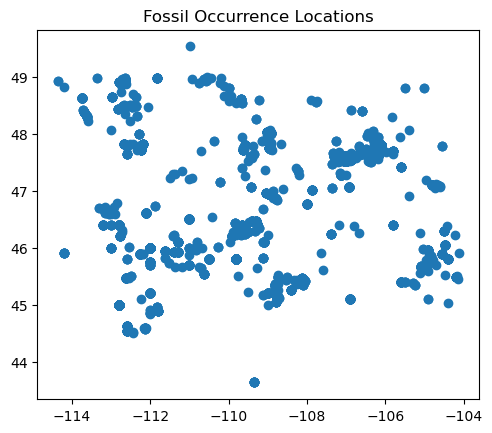

In [4]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lng'], df['lat']),
    crs="EPSG:4326"
)
gdf.plot()
plt.title("Fossil Occurrence Locations")
plt.show()

In [5]:
import os
import glob

In [6]:
shp_files = glob.glob("Geology_100KSeamless/**/*.shp", recursive=True)

for file in shp_files:
    print(file)

Geology_100KSeamless/Shapefiles/CartographicLines.shp
Geology_100KSeamless/Shapefiles/ObservationsFaults.shp
Geology_100KSeamless/Shapefiles/Quad_bdys_100k.shp
Geology_100KSeamless/Shapefiles/ContactsAndFaults.shp
Geology_100KSeamless/Shapefiles/OtherLines.shp
Geology_100KSeamless/Shapefiles/OrientationDataPoints.shp
Geology_100KSeamless/Shapefiles/Clinker.shp
Geology_100KSeamless/Shapefiles/GlacialAndSurficialLines.shp
Geology_100KSeamless/Shapefiles/MapUnitPolys.shp


In [7]:
geology = gpd.read_file(
    "Geology_100KSeamless/Shapefiles/MapUnitPolys.shp"
)

In [8]:
print(geology.head())
print(geology.geom_type.value_counts())

  MapUnitPol MapUnit                          MapUnitNam  \
0       None     Msp                Scott Peak Formation   
1       None     Tci  Challis Volcanics, intrusive rocks   
2       None    Qgdy  Glacial deposit, younger than Qgdo   
3       None      Qc                           Colluvium   
4       None     Mmd             Middle Canyon Formation   

                                          MapUnitDes  MapUnitAge MapUnitA_1  \
0  Dark gray, chert-bearing, fine grained limesto...           0       None   
1  Dark-gray to olive-gray, altered latitic intru...           0       None   
2  Loosely consolidated to unconsolidated drift o...           0       None   
3  Granule and larger size, unconsolidated, poorl...           0       None   
4  Dark gray, silty limestone with chert beds and...           0       None   

  MapUnitA_2 MapUnitA_3  MapUnitLit IdentityCo  ... meta_url MapUnitPar  \
0       None       None           0        NaN  ...     None       None   
1       None  

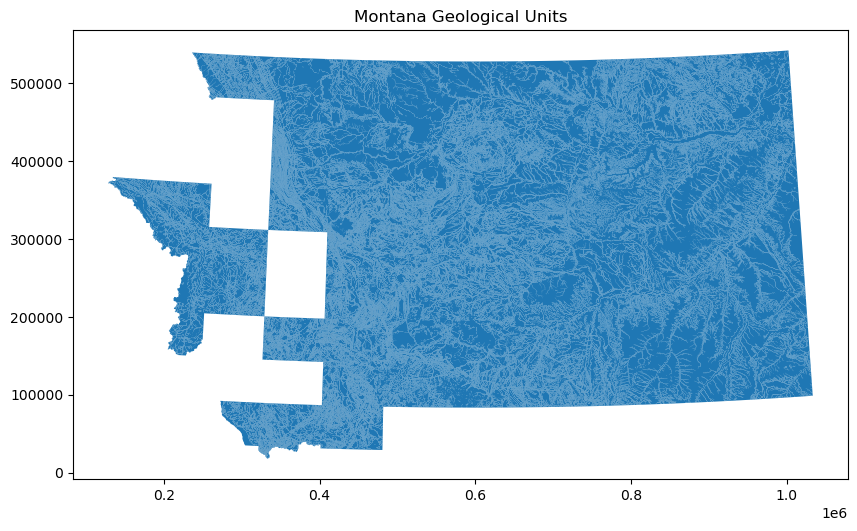

In [9]:
geology.plot(figsize=(10,10))
plt.title("Montana Geological Units")
plt.show()

In [10]:
print(geology.is_empty.sum())

0


In [11]:
dem_files = glob.glob("DEM/**/*.tif", recursive=True)

print(len(dem_files))

51


In [12]:
from rasterio.merge import merge

src_files = [rasterio.open(fp) for fp in dem_files]

mosaic, out_trans = merge(src_files)

print(mosaic.shape)

(1, 18001, 46801)


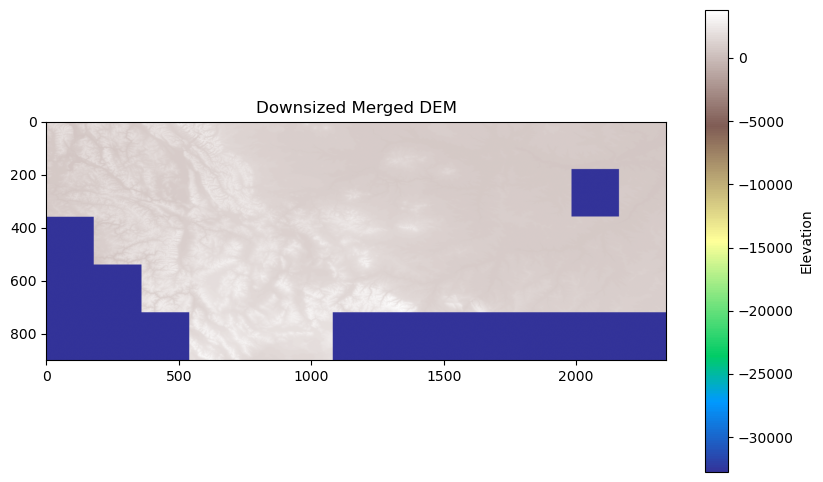

In [21]:
sample = mosaic[0, ::20, ::20]

plt.figure(figsize=(10, 6))
plt.imshow(sample, cmap="terrain")
plt.title("Downsized Merged DEM")
plt.colorbar(label="Elevation")
plt.show()

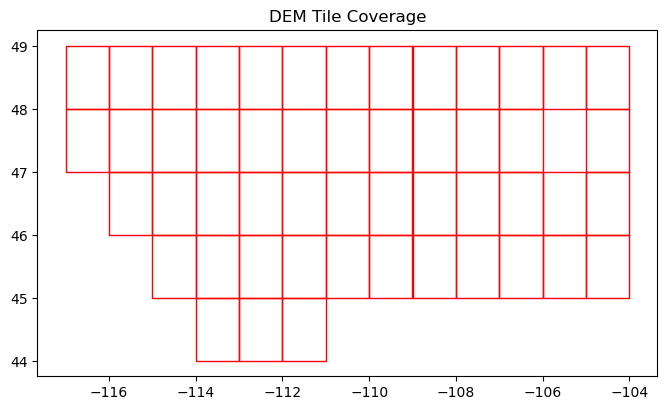

In [14]:
from shapely.geometry import box
boxes = []

for src in src_files:
    bounds = src.bounds
    geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
    boxes.append(geom)

tiles_gdf = gpd.GeoDataFrame(geometry=boxes, crs=src_files[0].crs)

tiles_gdf.plot(edgecolor="red", facecolor="none", figsize=(8,6))
plt.title("DEM Tile Coverage")
plt.show()

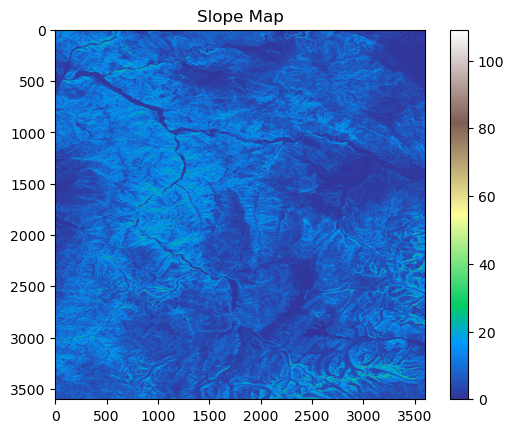

In [15]:
dem = rasterio.open(dem_files[0])
elevation = dem.read(1)

dx, dy = np.gradient(elevation)
slope = np.sqrt(dx**2 + dy**2)

plt.imshow(slope, cmap="terrain")
plt.title("Slope Map")
plt.colorbar()
plt.show()

In [18]:
nlcd_files = glob.glob("**/*NLCD*.tif", recursive=True)

for f in nlcd_files:
    print(f)

Annual_NLCD_LndCov_2024_CU_C1V1/Annual_NLCD_LndCov_2024_CU_C1V1.tif


In [19]:
nlcd = rasterio.open("Annual_NLCD_LndCov_2024_CU_C1V1/Annual_NLCD_LndCov_2024_CU_C1V1.tif")

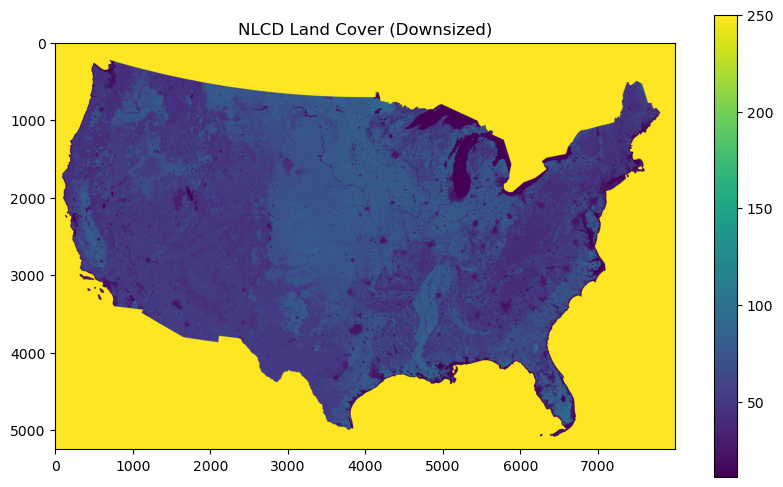

In [20]:
nlcd_data = nlcd.read(1)
nlcd_small = nlcd_data[::20, ::20]

plt.figure(figsize=(10,6))
plt.imshow(nlcd_small)
plt.title("NLCD Land Cover (Downsized)")
plt.colorbar()
plt.show()